## Reconstructing galaxy velocities

The linearized continuity equation predicts the velocity field relatively well as a first order approximation, as it uses information of the whole density field. However, this model cannot properly predict the correct amplitude in high density region,which can be modelled by my skew-t model. In this notebook, we combine both models and test whether this hybrid model can give outperform both individual models.

In [69]:
import numpy as np
from matplotlib import pyplot as plt
import my_functions as mf
from scipy.optimize import minimize
from importlib import reload
from scipy.optimize import curve_fit
import swiftsimio
reload(mf)

<module 'my_functions' from '/data2/quinten/MRP/hybrid_model/my_functions.py'>

In [70]:
def calc_correlation(array1, array2):
    covariance_matrix = np.cov(array1, array2)
    correlation = covariance_matrix[0, 1] / np.prod(np.diagonal(covariance_matrix))**.5
    return correlation

In [71]:
def rms_difference(array1, array2):
    return np.mean((array1 - array2)**2)**.5

In [72]:
def plot_mean_velocity_vs_n_g(ax, v_rec, n_g, **kwargs):
    n_gs = np.arange(np.max(n_g)+1)
    v_mean = [np.mean(v_rec[n_g == n]) for n in n_gs]

    ax.plot(n_gs, v_mean, **kwargs)

In [73]:
def plot_correlation_vs_n_g(ax, v_rec, v_true, n_g, **kwargs):
    n_gs = np.arange(np.max(n_g)+1)
    correlation = [calc_correlation(v_rec[n_g == n], v_true[n_g == n]) for n in n_gs]

    ax.scatter(n_gs, correlation, **kwargs)

In [106]:
def plot_rms_difference_vs_n_g(ax, v_rec, v_true, n_g, n_g_mean=None, **kwargs):
    n_gs = np.arange(np.max(n_g)+1)
    rms = [rms_difference(v_rec[n_g == n], v_true[n_g == n]) for n in n_gs]
    if n_g_mean:
        n_gs /= n_g_mean
    ax.plot(n_gs, rms, **kwargs)

In [75]:
fiducial = mf.load_simulation('L1m9_dmo_fiducial', '0077', '0+', 100)

In [76]:
skew_t9 = mf.load_model_t9(fiducial.simulation, fiducial.snapshot, fiducial.mass_tag, fiducial.bins, 10)
v_lin, v_t9, v_hybrid, v_true, n_g = mf.get_all_velocities(fiducial, skew_t9)

Note that the linearized continuity equation predicts sign, where my skew-t model does not. This is not a problem, as kSZ observations measure the product of electron density and bulk motion. Since electron density cannot be negative, the measurement always contains the sign of the velocity, so we directly take this from the observations. For this reason, we exclusively work with positive velocities.

After reconstructing the velocities using linear theory, we create a hybrid 'nonlinear' model. We make the following assumptions. The linearized continuity equation correctly models deviations of the mean expected velocity given the galaxy overdensity in a voxel, but does not correctly predict the mean expected velocity itself. The skew-t model perfectly predicts the mean expected velocity in a voxel, but does not measure deviations between voxels with the same number density. Taking the velocities from linear theory and simply shifting the mean of all voxels with the same number density to the velocity predicted by the skew-t model then predicts both the amplitude and its deviations.

/data2/quinten/.venv4/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/data2/quinten/.venv4/lib64/python3.12/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/tmp/zegveld/ipykernel_407502/3027487000.py:2: RuntimeWarning: Degrees of freedom <= 0 for slice
  covariance_matrix = np.cov(array1, array2)
/data2/quinten/.venv4/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/data2/quinten/.venv4/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


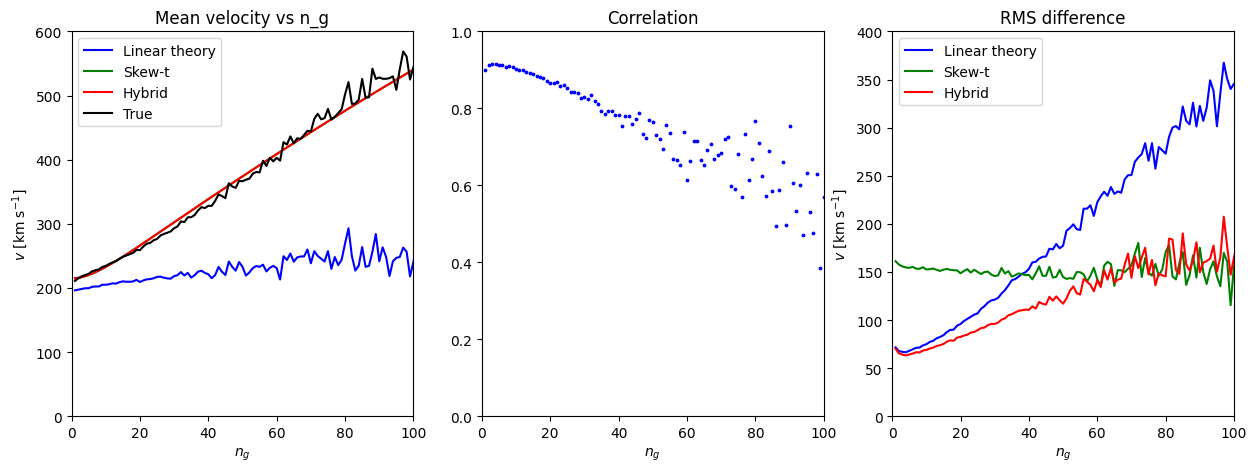

In [77]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=[15,5])

xlim=[0, 100]

plot_mean_velocity_vs_n_g(ax1, v_lin, n_g, c='b', label='Linear theory')
plot_mean_velocity_vs_n_g(ax1, v_t9, n_g, c='g', label='Skew-t')
plot_mean_velocity_vs_n_g(ax1, v_hybrid, n_g, c='r', label='Hybrid')
plot_mean_velocity_vs_n_g(ax1, v_true, n_g, c='black', label='True')
ax1.set(
    title='Mean velocity vs n_g',
    xlim=xlim,
    ylim=[0, 600],
    xlabel='$n_g$',
    ylabel='$v$ [km s$^{-1}$]',
)

ax1.legend()

plot_correlation_vs_n_g(ax2, v_lin, v_true, n_g, c='b', label='Correlation', s=3)
ax2.set(xlim=xlim, ylim=[0, 1], xlabel='$n_g$', title='Correlation')

plot_rms_difference_vs_n_g(ax3, v_lin, v_true, n_g, c='b', label='Linear theory')
plot_rms_difference_vs_n_g(ax3, v_t9, v_true, n_g, c='g', label='Skew-t')
plot_rms_difference_vs_n_g(ax3, v_hybrid, v_true, n_g, c='r', label='Hybrid')
ax3.set(xlim=xlim, ylim=[0, 400], xlabel='$n_g$', ylabel='$v$ [km s$^{-1}$]', title='RMS difference')

ax3.legend()
plt.show()

The first panel shows the mean velocity in each number density bin for different velocity reconstruction mechanisms. Linear theory underpredicts the mean velocity, which increases substantially with numer density. The skew-t model and hybrid model have identical means and nicely follow the true velocities.

The second panel shows the correlation coefficient between linear theory and true velocities. The correlation drops with increasing number density, indicating that the deviations of the mean are also modelled more poorly with increasing number density, not just the amplitude.

The third panel shows the RMS velocity difference between true and reconstructed velocities. The hybrid model clearly performs better than both individual models, except at very high number density.

Four important tests:
1. Test model for different cosmologies
2. Include $d^2\delta_g/dx^2$ in model
3. Go to redshift space
4. Test the effect of using non-periodic volumes (include only a part of the box)

### 1) Testing different cosmologies

We verify the dependence on cosmology by observing the performance of linear theory (based on the fiducial cosmology) and the fiducial skew-t model in other cosmologies and in the fiducial hydrodynamical simulation.

In [107]:
def rms_difference_per_cosmology(ax, simulation, model_t9, n_g_mean_fiducial, to_overdensity=False, **kwargs):
    density_ratio = simulation.mean_galaxy_number_density / n_g_mean_fiducial
    v_lin, v_t9, v_hybrid, v_true, n_g = mf.get_all_velocities(simulation, model_t9, density_ratio)

    if to_overdensity:
        n_g_mean = simulation.mean_galaxy_number_density
    else:
        n_g_mean = None
    plot_rms_difference_vs_n_g(ax, v_lin, v_true, n_g, n_g_mean=n_g_mean, c='b', label='Linear theory')
    plot_rms_difference_vs_n_g(ax, v_t9, v_true, n_g, n_g_mean=n_g_mean, c='g', label='Skew-t')
    plot_rms_difference_vs_n_g(ax, v_hybrid, v_true, n_g, n_g_mean=n_g_mean, c='r', label='Hybrid')
    
    ax.set(**kwargs)
    ax.legend()

In [79]:
fiducial = mf.load_simulation('L1m9_dmo_fiducial', '0077', '0+', 100)
planck = mf.load_simulation('L1m9_dmo_planck', '0077', '0+', 100)
ls8 = mf.load_simulation('L1m9_dmo_ls8', '0077', '0+', 100)
hydro = mf.load_simulation('L1m9_hydro_fiducial', '0077', '0+', 100)
fiducial_large = mf.load_simulation('L2p8m9_dmo_fiducial', '0078', '0+', 280)

In [80]:
skew_t9_fiducial = mf.load_model_t9('L1m9_dmo_fiducial', '0077', '0+', 100, 10)
skew_t9_planck = mf.load_model_t9('L1m9_dmo_planck', '0077', '0+', 100, 10)
skew_t9_ls8 = mf.load_model_t9('L1m9_dmo_ls8', '0077', '0+', 100, 10)
skew_t9_hydro = mf.load_model_t9('L1m9_hydro_fiducial', '0077', '0+', 100, 10)

In [86]:
n_gs = np.arange(2, 100)
skew_t_mean_fiducial = mf.skew_t_mean(*mf.t9_to_skew_t_params(n_gs, skew_t9_fiducial))
skew_t_mean_planck = mf.skew_t_mean(*mf.t9_to_skew_t_params(n_gs, skew_t9_planck))
skew_t_mean_ls8 = mf.skew_t_mean(*mf.t9_to_skew_t_params(n_gs, skew_t9_ls8))
skew_t_mean_hydro = mf.skew_t_mean(*mf.t9_to_skew_t_params(n_gs, skew_t9_hydro))


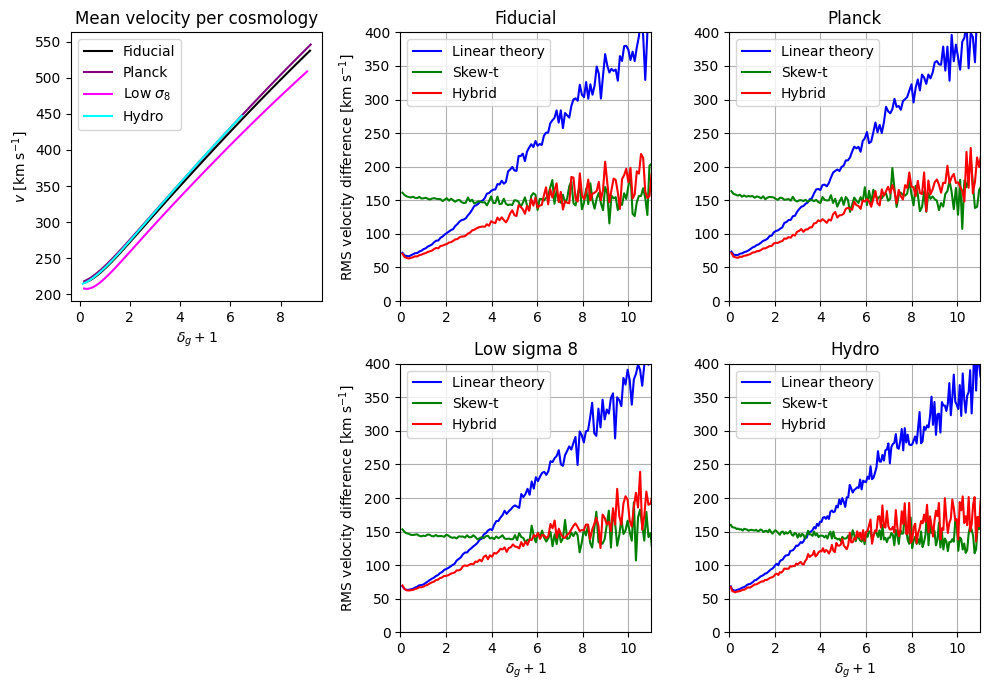

In [116]:
reload(mf)
fig, ax = plt.subplots(2,3, figsize=[10,7])
ax1, ax2, ax3, ax4, ax5, ax6 = ax.flatten()

ax1.plot(n_gs/fiducial.mean_galaxy_number_density, skew_t_mean_fiducial, c='black', label='Fiducial')
ax1.plot(n_gs/planck.mean_galaxy_number_density, skew_t_mean_planck, c='purple', label='Planck')
ax1.plot(n_gs/ls8.mean_galaxy_number_density, skew_t_mean_ls8, c='magenta', label=r'Low $\sigma_8$')
ax1.plot(n_gs/hydro.mean_galaxy_number_density, skew_t_mean_hydro, c='aqua', label=r'Hydro')
ax1.set(title='Mean velocity per cosmology', ylabel='$v$ [km s$^{-1}$]', xlabel=r'$\delta_g+1$')
ax1.legend()

n_g_mean = fiducial.mean_galaxy_number_density
rms_difference_per_cosmology(ax2, fiducial, skew_t9_fiducial, n_g_mean, to_overdensity=True, xlim=[0, 11], ylim=[0, 400], title='Fiducial', ylabel='RMS velocity difference [km s$^{-1}$]')
rms_difference_per_cosmology(ax3, planck, skew_t9_fiducial, n_g_mean, to_overdensity=True, xlim=[0, 11], ylim=[0, 400], title='Planck')
rms_difference_per_cosmology(ax5, ls8, skew_t9_fiducial, n_g_mean, to_overdensity=True, xlim=[0, 11], ylim=[0, 400], title='Low sigma 8', xlabel=r'$\delta_g+1$', ylabel='RMS velocity difference [km s$^{-1}$]')
rms_difference_per_cosmology(ax6, hydro, skew_t9_fiducial, n_g_mean, to_overdensity=True, xlim=[0, 11], ylim=[0, 400], title='Hydro', xlabel=r'$\delta_g+1$')
ax4.axis('off')

for axis in ax[:, 1:].flatten():
    axis.grid()

fig.tight_layout()
plt.show()

The plot above shows that the hybrid model is not significantly dependent on cosmology.